In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

import utils

In [2]:
OUTPUTS_DIR = Path("/Users/hyeon/SeSAC_Project/PoC/run/test7/outputs")
hpe = OUTPUTS_DIR / "pose_predictions.json"

with hpe.open(mode= "r", encoding= 'utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode= "r", encoding= 'utf-8') as file:
    detail_data = json.load(file)

In [3]:
class PoseSequence:
    def __init__(self, pose_data: dict, detail_data: dict):
        """
        json 데이터를 불러온 뒤 바로 이 클래스의 인자로 입력하면 됩니다.
        y좌표는 0의 기준이 위에서 아래로 바뀝니다.
        """
        # bbox, keypoints들의 y좌표 반전.
        df = utils.hpe2pd(pose_data)
        _cols = df.columns[df.columns.str.contains("_y|up|down")]
        df.loc[:, _cols] = detail_data["video"]["height"] - df[_cols]

        # direction
        dir_index = 0 if (df["nose_x"] - df["neck_x"])[0] > 0 else 1

        self.df = df
        self.details = detail_data
        self.direction = "left" if dir_index else "right"
        self.strides = []

    def cal_stride(self) -> None:
        """
        self.stride에 1스트라이드의 시작, 끝 프레임 기록
        """
        if self.strides:
            print('이미 stride가 계산되어 있습니다.')
            print('Stride :', self.strides)
            return
        df = self.df
        dir = self.direction
        left_knee_angle = utils.knee_flexion_angle(
            [df[f"{dir}_hip_x"], df[f"{dir}_hip_y"]],
            [df[f"{dir}_knee_x"], df[f"{dir}_knee_y"]],
            [df[f"{dir}_ankle_x"], df[f"{dir}_ankle_y"]]
        )
        y = np.asarray(left_knee_angle, dtype=float)
        y_smooth = savgol_filter(
            y,
            window_length=5,
            polyorder=2
        )
        # 데이터 범위에 비례해 prominence 설정
        signal_range = np.percentile(y_smooth, 95) - np.percentile(y_smooth, 5)
        prominence = signal_range * 0.10    # 곱해지는 숫자가 클수록 큰 봉우리만 검출

        # 최댓값
        max_indices, max_properties = find_peaks(
            y_smooth,
            prominence=prominence,
            distance=10,
        )

        # 최솟값: 신호에 -를 붙여서 봉우리로 변환
        min_indices, min_properties = find_peaks(
            -y_smooth,
            prominence=prominence,
            distance=10,
        )

        _max = {
            "frame": max_indices,
            "class": np.ones_like(max_indices)
        }
        _min = {
            "frame": min_indices,
            "class": np.zeros_like(min_indices)
        }
        extremum = pd.concat([pd.DataFrame(_max), pd.DataFrame(_min)]).sort_values('frame')

        assert len(extremum) >= 2, "온전한 스트라이드가 검출되지 않았습니다."
        # 올바른 스트라이드 검출
        for i in range(1, len(extremum)):
            previous = extremum["class"].iloc[i - 1]
            current = extremum["class"].iloc[i]

            assert {previous, current} == {0, 1}, (
                f"예외: {i-1}, {i}행의 값이 {previous}, {current}입니다.\n올바른 스트라이드가 검출되지 않았습니다. 검출 파라미터 변경 필요."
            )
        for i in range(len(extremum) // 4 + 1):
            self.strides.append(extremum['frame'].iloc[4 * i : 4 * i + 5].to_list())
    def gct(self, next: int = 0):
        """
        {side}의 heel이 지면에 접촉하고 big_toe가 지면에서 떼어지는 순간까지의 인덱스 출력
        """
        n = len(self.strides) - (0 if len(self.strides[-1]) == 5 else 1)
        res = []
        for i in range(n):
            start = self.strides[i][0]
            end = self.strides[i][-1]

            df = self.df.loc[start:end+1]

            heel = f"{self.direction}_heel"
            td = int(df[f"{heel}_y"].idxmin())

            toe = f"{self.direction}_big_toe"
            min_value = df[f"{toe}_y"].min()

            inside = df[f"{toe}_y"].between(min_value, min_value + 5)
            to = df.index[~inside & inside.shift(1, fill_value=False)].to_list()[0]

            res.append([td, to])
        return res

In [4]:
ps = PoseSequence(pose_data, detail_data)

In [5]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1566.204346,824.780731,1885.789673,131.141235,1606.326179,748.913948,1618.744856,761.332625,1607.455149,763.590566,...,1618.744856,150.559518,1871.634288,214.910843,1621.002797,153.946430,1869.376346,299.583640,1710.191481,160.720253
1,1558.756836,809.283539,1868.142700,131.089966,1585.405339,745.040621,1597.547477,757.182759,1585.405339,758.286589,...,1618.520262,152.283516,1842.597906,203.059730,1621.831754,156.698839,1838.182583,294.677681,1709.034384,161.114162
2,1544.564941,807.803619,1829.895386,128.031921,1565.526299,745.624009,1578.803091,757.794402,1566.632698,758.900801,...,1617.527067,151.487586,1808.934150,202.381954,1624.165463,155.913184,1807.827751,286.468301,1702.719815,158.125982
3,1412.392090,804.579803,1802.677368,127.116516,1547.991997,747.021870,1561.223701,759.150932,1550.197281,761.356216,...,1616.355804,150.492516,1766.315125,190.187630,1625.176941,156.005726,1776.238903,262.962006,1697.951317,158.211010
4,1409.595337,806.982117,1764.418335,129.436890,1529.662517,749.417203,1541.793046,761.547733,1531.868068,762.650508,...,1617.884546,150.610153,1722.648205,189.207293,1624.501198,156.124030,1742.498162,259.784919,1692.873271,158.329581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,109.225418,792.956787,401.628021,132.773071,180.210483,739.015985,190.955661,748.686645,185.583072,751.910198,...,368.251094,206.055192,174.837894,150.180271,380.070790,217.874887,255.426727,159.850930,363.953023,304.910823
74,94.365807,791.317200,313.994934,137.031372,160.518724,735.728498,170.102988,746.377682,165.843315,748.507518,...,330.905653,201.139482,175.427580,151.088319,339.424999,218.178175,247.842025,161.737502,330.905653,295.917216
75,69.426704,791.452332,290.821320,136.465210,140.679797,736.870036,151.340395,747.530633,144.944036,749.662753,...,283.531804,197.443803,176.925829,149.471114,293.126342,212.368640,253.682131,163.329891,301.654819,286.992822
76,48.431145,793.649048,289.958832,129.179810,122.690795,740.439597,131.342739,752.336019,128.098260,753.417512,...,243.818006,195.367175,178.928429,148.862980,248.143978,206.182104,249.225471,164.003881,273.018316,272.153171


In [6]:
ps.direction

'left'

In [7]:
ps.cal_stride()

In [8]:
ps.strides

[[16, 27, 35, 49, 65], [65]]

In [63]:
ps.df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y'],
      dtype='str')

In [65]:
direction = 'left'

In [94]:
image = ps.df.loc[ps.strides[0][0]]

In [95]:
image

bbox_left            1229.914673
bbox_up               863.532440
bbox_right           1598.727905
bbox_down             144.043762
nose_x               1303.072227
nose_y                794.206690
left_eye_x           1315.953697
left_eye_y            804.746075
right_eye_x          1301.901184
right_eye_y           808.259204
left_ear_x           1355.769151
left_ear_y            790.693562
right_ear_x          1303.072227
right_ear_y           800.061904
left_shoulder_x      1396.755648
left_shoulder_y       732.141424
right_shoulder_x     1310.098483
right_shoulder_y      711.062654
left_elbow_x         1461.162999
left_elbow_y          647.826345
right_elbow_x        1351.084980
right_elbow_y         618.550276
left_wrist_x         1381.532092
left_wrist_y          616.208191
right_wrist_x        1297.217013
right_wrist_y         590.445250
left_hip_x           1379.190006
left_hip_y            521.353727
right_hip_x          1346.400809
right_hip_y           516.669556
left_knee_

In [ ]:
def _point(df, name):
    return df[[f"{name}_x", f"{name}_y"]].to_numpy(dtype=float)


left_ankle = _point(ps.df, "left_ankle")
left_knee = _point(ps.df, "left_knee")
left_hip = _point(ps.df, "left_hip")

right_ankle = _point(ps.df, "right_ankle")
right_knee = _point(ps.df, "right_knee")
right_hip = _point(ps.df, "right_hip")

hip_center = _point(ps.df, "hip_center")
neck = _point(ps.df, "neck")
head = _point(ps.df, "head")

In [97]:
left_ankle

array([1297.21701304,  198.14592552])

In [83]:
def distance(a, b):
    return np.linalg.norm(a - b, axis=1)


left_leg = (
    distance(left_ankle, left_knee)
    + distance(left_knee, left_hip)
)

right_leg = (
    distance(right_ankle, right_knee)
    + distance(right_knee, right_hip)
)

leg_length = np.nanmean(
    np.column_stack([left_leg, right_leg]),
    axis=1,
)

torso_length = distance(hip_center, neck)
head_length = distance(neck, head)

height_px = leg_length + torso_length + head_length

In [ ]:
def pixel2m(height: float):
    """
    사용자의 키 정보를 사용해 1pixel을 m단위로 변경한다.
    이 때 사용하는 이미지는 TD시점이다.
    """
    

In [87]:
right_leg.mean()

np.float64(301.3415372104507)

In [88]:
left_leg.mean()

np.float64(323.57727276447133)

In [85]:
height_px.mean()

np.float64(641.2726446100859)

In [62]:
help(np.hypot)

Help on ufunc in module numpy:

hypot = <ufunc 'hypot'>
    hypot(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Given the "legs" of a right triangle, return its hypotenuse.

    Equivalent to ``sqrt(x1**2 + x2**2)``, element-wise.  If `x1` or
    `x2` is scalar_like (i.e., unambiguously cast-able to a scalar type),
    it is broadcast for use with each element of the other argument.
    (See Examples)

    Parameters
    ----------
    x1, x2 : array_like
        Leg of the triangle(s).
        If ``x1.shape != x2.shape``, they must be broadcastable to a common
        shape (which becomes the shape of the output).
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument)

In [9]:
strides = ps.gct()

In [10]:
strides

[[21, 36]]

In [11]:
for i in range(len(strides)):
    start, end = strides[i]

In [12]:
start

21

In [13]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1566.204346,824.780731,1885.789673,131.141235,1606.326179,748.913948,1618.744856,761.332625,1607.455149,763.590566,...,1618.744856,150.559518,1871.634288,214.910843,1621.002797,153.946430,1869.376346,299.583640,1710.191481,160.720253
1,1558.756836,809.283539,1868.142700,131.089966,1585.405339,745.040621,1597.547477,757.182759,1585.405339,758.286589,...,1618.520262,152.283516,1842.597906,203.059730,1621.831754,156.698839,1838.182583,294.677681,1709.034384,161.114162
2,1544.564941,807.803619,1829.895386,128.031921,1565.526299,745.624009,1578.803091,757.794402,1566.632698,758.900801,...,1617.527067,151.487586,1808.934150,202.381954,1624.165463,155.913184,1807.827751,286.468301,1702.719815,158.125982
3,1412.392090,804.579803,1802.677368,127.116516,1547.991997,747.021870,1561.223701,759.150932,1550.197281,761.356216,...,1616.355804,150.492516,1766.315125,190.187630,1625.176941,156.005726,1776.238903,262.962006,1697.951317,158.211010
4,1409.595337,806.982117,1764.418335,129.436890,1529.662517,749.417203,1541.793046,761.547733,1531.868068,762.650508,...,1617.884546,150.610153,1722.648205,189.207293,1624.501198,156.124030,1742.498162,259.784919,1692.873271,158.329581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,109.225418,792.956787,401.628021,132.773071,180.210483,739.015985,190.955661,748.686645,185.583072,751.910198,...,368.251094,206.055192,174.837894,150.180271,380.070790,217.874887,255.426727,159.850930,363.953023,304.910823
74,94.365807,791.317200,313.994934,137.031372,160.518724,735.728498,170.102988,746.377682,165.843315,748.507518,...,330.905653,201.139482,175.427580,151.088319,339.424999,218.178175,247.842025,161.737502,330.905653,295.917216
75,69.426704,791.452332,290.821320,136.465210,140.679797,736.870036,151.340395,747.530633,144.944036,749.662753,...,283.531804,197.443803,176.925829,149.471114,293.126342,212.368640,253.682131,163.329891,301.654819,286.992822
76,48.431145,793.649048,289.958832,129.179810,122.690795,740.439597,131.342739,752.336019,128.098260,753.417512,...,243.818006,195.367175,178.928429,148.862980,248.143978,206.182104,249.225471,164.003881,273.018316,272.153171


In [15]:
ps.df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y'],
      dtype='str')

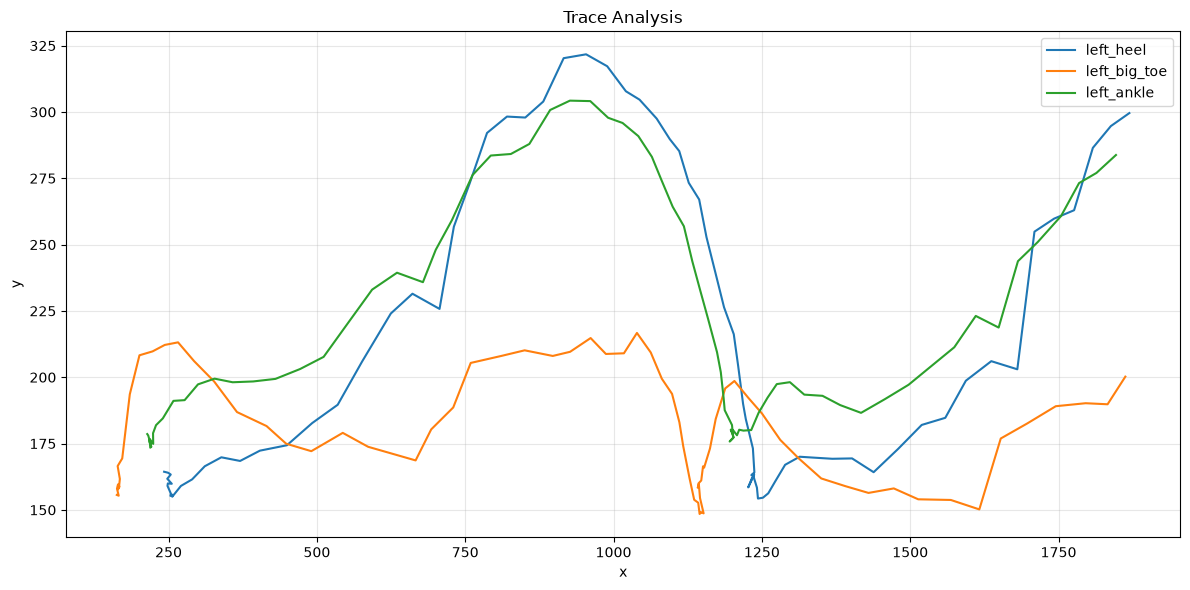

In [14]:
utils.visualize_xy(ps.df[["left_heel_x", "left_heel_y", "left_big_toe_x", "left_big_toe_y", "left_ankle_x", "left_ankle_y"]])

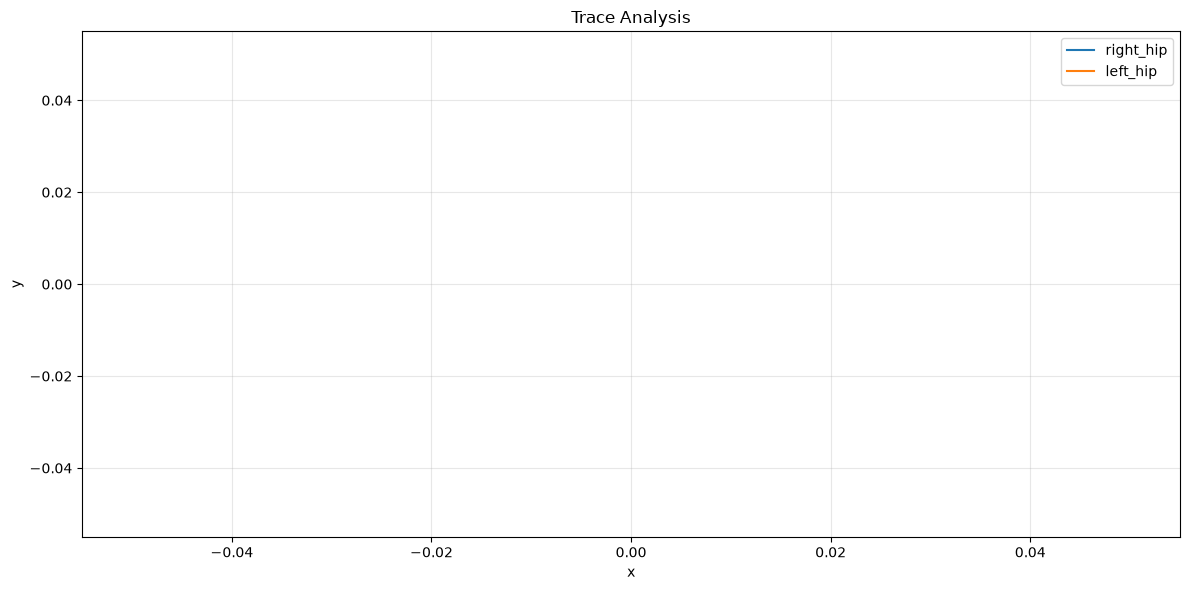

In [20]:
utils.visualize_xy((ps.df[["left_hip_x", "left_hip_y"]] + ps.df[["right_hip_x", "right_hip_y"]]).loc[start:end])

In [22]:
hip_center = pd.DataFrame({
    "hip_center_x": (
        ps.df["left_hip_x"] + ps.df["right_hip_x"]
    ) / 2,
    "hip_center_y": (
        ps.df["left_hip_y"] + ps.df["right_hip_y"]
    ) / 2,
})

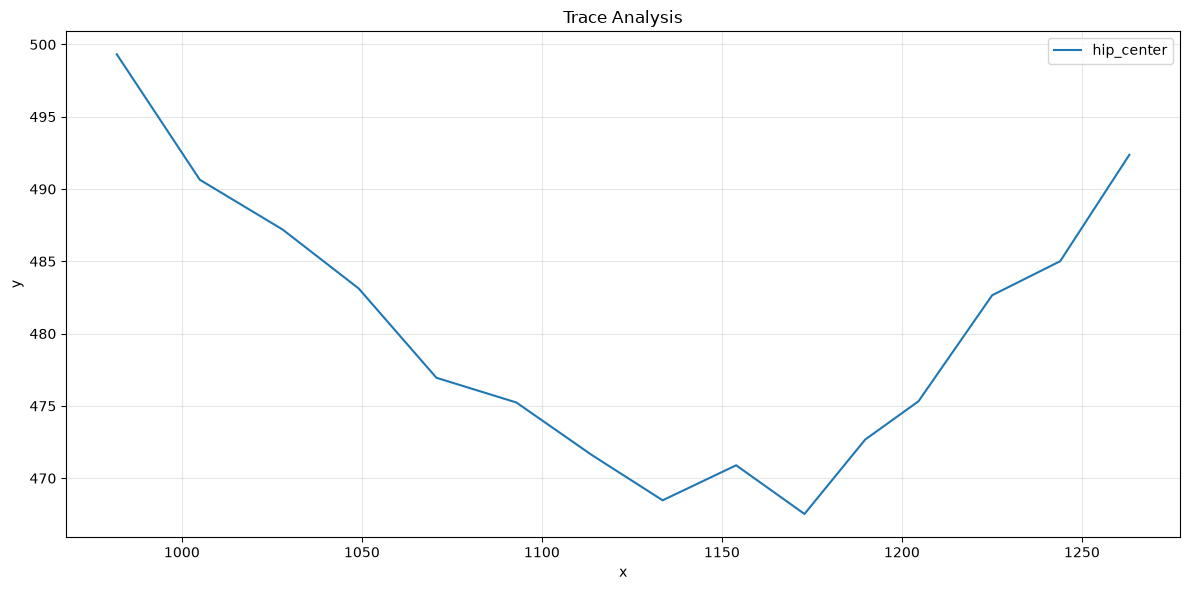

In [24]:
utils.visualize_xy(hip_center[start:end])

In [27]:
hip_center[start:end]['hip_center_y'].agg(['min', 'max'])

min    467.527719
max    499.317486
Name: hip_center_y, dtype: float64

In [45]:
hip_center = ps.df[
    ["left_hip_y", "right_hip_y"]
].mean(axis=1)

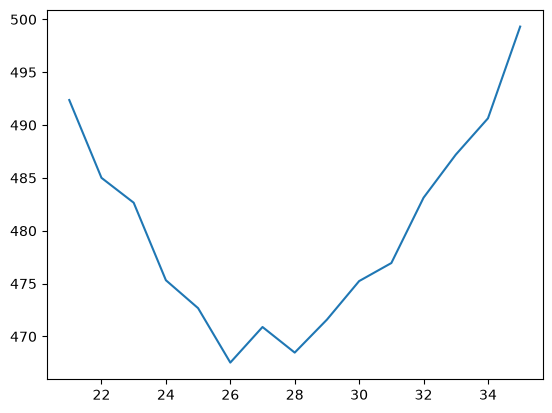

In [52]:
plt.plot(hip_center[21:36])

In [54]:
a = hip_center[21:36].agg(['min', 'max'])

In [55]:
a

min    467.527719
max    499.317486
dtype: float64

In [57]:
a.diff()['max']

np.float64(31.789767742156982)

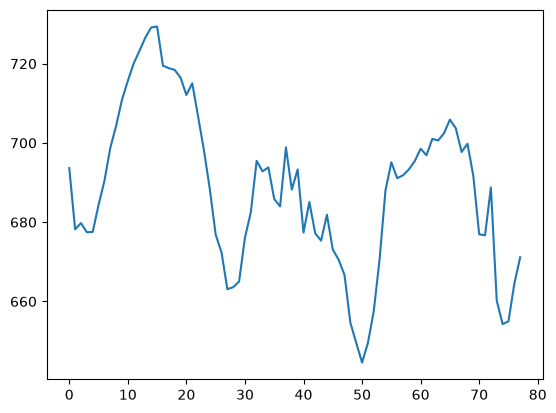

In [61]:
plt.plot(ps.df['bbox_up'] - ps.df['bbox_down'])